# H1 — Sélectivité accrue des IPOs 2022-2024 vs 2019-2021

**Hypothèse testée** : Les entreprises introduites en bourse sur la période **2022-2024**
affichent un **chiffre d'affaires médian** et une **part d'entreprises rentables**
(rentabilité nette LTM positive au moment de l'IPO) **significativement supérieurs**
à ceux des entreprises de la cohorte **2019-2021**.

---

**Méthodologie** :
1. Statistiques descriptives comparatives (médianes, proportions)
2. Intervalles de confiance à 95 % (bootstrap pour les médianes, Wilson pour les proportions)
3. Test de Mann-Whitney U (chiffre d'affaires)
4. Test Z pour les proportions (part d'entreprises rentables)
5. Régression OLS multivariée (variable de contrôle)

**Sources de données** :
- `dataset_complet_final.xlsx` : données de base (tickers, années, taille, underpricing, etc.)
- `SCOOP-Rating-Performance.xlsx` : chiffre d'affaires LTM et rentabilité au moment de l'IPO
- Critères d'exclusion appliqués : émissions < 50 M$, SPACs, Direct Listings


## 0. Imports et configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (10, 6), "figure.dpi": 100})

COLORS = {"c1": "#2C7BB6", "c2": "#D7191C"}   # cohorte 2019-2021 (bleu), 2022-2024 (rouge)
print("✓ Imports OK")

✓ Imports OK


## 1. Chargement et préparation des données

In [2]:
# ── 1a. Base principale ──────────────────────────────────────────────────────
df_base = pd.read_excel("data/dataset_complet_filled.xlsx")
print(f"Base principale : {len(df_base)} lignes")
print("Colonnes :", df_base.columns.tolist())
df_base.head(3)


Base principale : 782 lignes
Colonnes : ['ticker', 'year', 'ipo_date', 'open_px', 'close_px', 'underpricing', 'ret_30d', 'ret_12m', 'ipo_size_m', 'fed_rate', 'sic', 'sector', 'pe_backed', 'cohort', 'cohort_en', 'log_size', 'company_age', 'revenue_ltm', 'profitable']


,ticker,year,ipo_date,open_px,close_px,underpricing,ret_30d,ret_12m,ipo_size_m,fed_rate,sic,sector,pe_backed,cohort,cohort_en,log_size,company_age,revenue_ltm,profitable
0,PINS,2019,1970-01-01 01:00:43.573,23.750000,24.400000,0.027368,0.000000,NaN,2068.850625,2.16,7370.0,Tech,1,Taux bas (2019–2021),Low Rate (2019–2021),7.634748,11.0,1142.761,0.0
1,REAL,2019,1970-01-01 01:00:43.644,28.000000,28.900000,0.032143,-0.381315,NaN,550.765600,2.16,5900.0,Consumer,1,Taux bas (2019–2021),Low Rate (2019–2021),6.311309,8.0,316.354,0.0
2,SNDL,2019,1970-01-01 01:00:43.678,130.199997,84.800003,-0.348694,0.031840,NaN,121.273485,2.16,2833.0,Industrials,1,Taux bas (2019–2021),Low Rate (2019–2021),4.798048,13.0,NaN,NaN


In [ ]:
# ── 1b. Exploration du fichier SCOOP ────────────────────────────────────────
# Ce fichier contient les données financières (CA, rentabilité) au moment de l'IPO
xl_scoop = pd.ExcelFile("data/SCOOP-Rating-Performance.xlsx")
print("Feuilles disponibles dans SCOOP :", xl_scoop.sheet_names)

Feuilles disponibles dans SCOOP : ['SCOOP Scorecard', 'Sheet2', 'Sheet3']


In [18]:
# ── 1c. Lecture de chaque feuille pour identifier la structure ───────────────
for sheet in xl_scoop.sheet_names[:5]:          # on affiche les 5 premières feuilles
    df_tmp = xl_scoop.parse(sheet, nrows=5)
    print(f"\n=== Feuille : {sheet} ===")
    print(df_tmp.to_string())



=== Feuille : SCOOP Scorecard ===
  Unnamed: 0   Unnamed: 1 Unnamed: 2            IPO SCOOP Rating Scorecard  Unnamed: 4       Unnamed: 5
0        NaN          NaN        NaN  (First published online in May 2000)         NaN              NaN
1        NaN          NaN        NaN                                   NaN         NaN              NaN
2       Year  IPOs Priced      Calls                             On Target         NaN  Batting Average
3       2020          205        198                                   180        18.0         0.909091
4       2019          231        207                                   186        21.0         0.898551

=== Feuille : Sheet2 ===
Empty DataFrame
Columns: []
Index: []

=== Feuille : Sheet3 ===
Empty DataFrame
Columns: []
Index: []


In [19]:
# ── 1d. Construction du dataset SCOOP enrichi ────────────────────────────────
#
# NOTE : Adaptez cette cellule en fonction de ce que vous observez dans la
# cellule précédente.  Le code ci-dessous est un exemple générique qui tente
# de lire chaque feuille puis d'en extraire les colonnes utiles.
# Modifiez `SHEET`, `COL_TICKER`, `COL_REVENUE`, `COL_PROFITABLE` selon
# la structure réelle du fichier SCOOP.
#
# Exemple attendu : une feuille par année (ou une seule feuille globale) avec
# au minimum un identifiant (ticker ou nom), le CA (M$) et un indicateur de
# rentabilité (booléen ou flag).

scoop_records = []

for sheet in xl_scoop.sheet_names:
    df_s = xl_scoop.parse(sheet, header=None)   # header=None → on explore
    # Affichez les 3 premières lignes pour ajuster
    print(f"\n=== {sheet} ===")
    print(df_s.head(3).to_string())
    print("Shape :", df_s.shape)

print("\n(Adaptez la lecture ci-dessus selon la structure réelle du fichier.)")



=== SCOOP Scorecard ===
    0    1    2                                     3    4    5    6    7    8    9    10   11
0  NaN  NaN  NaN            IPO SCOOP Rating Scorecard  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
1  NaN  NaN  NaN  (First published online in May 2000)  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2  NaN  NaN  NaN                                   NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
Shape : (3773, 12)

=== Sheet2 ===
Empty DataFrame
Columns: []
Index: []
Shape : (0, 0)

=== Sheet3 ===
Empty DataFrame
Columns: []
Index: []
Shape : (0, 0)

(Adaptez la lecture ci-dessus selon la structure réelle du fichier.)


In [20]:
# ── 1e. Fallback : si revenue_ltm et profitable sont déjà dans df_base ──────
#
# Si les colonnes revenue_ltm / profitable existent et contiennent des données
# exploitables, on les utilise directement.  Sinon, on construit un proxy
# à partir des informations disponibles.
#
# Vérification :
print("Valeurs non-nulles dans revenue_ltm :", df_base["revenue_ltm"].notna().sum())
print("Valeurs non-nulles dans profitable   :", df_base["profitable"].notna().sum())


Valeurs non-nulles dans revenue_ltm : 0
Valeurs non-nulles dans profitable   : 0


In [3]:
# ── 1f. Simulation prudente (proxy) ─────────────────────────────────────────
#
# Si revenue_ltm / profitable sont TOUS vides, on génère des valeurs
# simulées cohérentes avec la réalité économique documentée dans la
# littérature (Ritter 2024) afin de pouvoir tester l'hypothèse H1.
#
# ► 2019-2021 : période de « boom » — beaucoup de licornes pré-rentables
#   → revenu médian ~150 M$, ~35 % d'entreprises rentables
# ► 2022-2024 : période de « normalisation » — sélection plus stricte
#   → revenu médian ~280 M$, ~55 % d'entreprises rentables
#
# L'objectif est académique ; le notebook indique clairement qu'il s'agit
# de valeurs simulées si les données réelles ne sont pas disponibles.

np.random.seed(42)

if df_base["revenue_ltm"].notna().sum() == 0:
    print("⚠ revenue_ltm entièrement vide — génération de données simulées.")
    USE_SIMULATED = True

    mask_2019_2021 = df_base["year"].between(2019, 2021)
    mask_2022_2024 = df_base["year"].between(2022, 2024)

    # Chiffre d'affaires LTM (log-normal, en M$)
    rev_c1 = np.random.lognormal(mean=np.log(150), sigma=1.2, size=mask_2019_2021.sum())
    rev_c2 = np.random.lognormal(mean=np.log(280), sigma=1.0, size=mask_2022_2024.sum())

    df_base.loc[mask_2019_2021, "revenue_ltm"] = rev_c1.round(1)
    df_base.loc[mask_2022_2024, "revenue_ltm"] = rev_c2.round(1)

    # Rentabilité (Bernoulli)
    prof_c1 = (np.random.rand(mask_2019_2021.sum()) < 0.35).astype(int)
    prof_c2 = (np.random.rand(mask_2022_2024.sum()) < 0.55).astype(int)

    df_base.loc[mask_2019_2021, "profitable"] = prof_c1
    df_base.loc[mask_2022_2024, "profitable"] = prof_c2
else:
    USE_SIMULATED = False
    print("✓ Données réelles trouvées dans revenue_ltm et profitable.")

print(f"\nValeurs non-nulles revenue_ltm : {df_base['revenue_ltm'].notna().sum()}")
print(f"Valeurs non-nulles profitable   : {df_base['profitable'].notna().sum()}")


✓ Données réelles trouvées dans revenue_ltm et profitable.

Valeurs non-nulles revenue_ltm : 703
Valeurs non-nulles profitable   : 703


In [4]:
# ── 1g. Filtres & cohortes ────────────────────────────────────────────────────

# 1. Taille de l'émission ≥ 50 M$
df = df_base[df_base["ipo_size_m"] >= 50].copy()
print(f"Après filtre taille ≥ 50 M$ : {len(df)} IPOs")

# 2. Création des cohortes
df["cohort_period"] = np.where(
    df["year"].between(2019, 2021), "2019-2021",
    np.where(df["year"].between(2022, 2024), "2022-2024", "Autre")
)

# 3. Restriction aux deux cohortes d'intérêt
df = df[df["cohort_period"].isin(["2019-2021", "2022-2024"])].copy()
print(f"Après restriction aux cohortes : {len(df)} IPOs")
print(df["cohort_period"].value_counts())

# 4. Suppression des lignes sans revenue_ltm ni profitable
df = df.dropna(subset=["revenue_ltm", "profitable"])
print(f"\nAprès suppression des NaN (revenue_ltm / profitable) : {len(df)} IPOs")
print(df["cohort_period"].value_counts())

c1 = df[df["cohort_period"] == "2019-2021"].copy()
c2 = df[df["cohort_period"] == "2022-2024"].copy()

if USE_SIMULATED:
    print("\n⚠ ATTENTION : données simulées — résultats à interpréter avec précaution.")


Après filtre taille ≥ 50 M$ : 321 IPOs
Après restriction aux cohortes : 321 IPOs
cohort_period
2019-2021    237
2022-2024     84
Name: count, dtype: int64

Après suppression des NaN (revenue_ltm / profitable) : 291 IPOs
cohort_period
2019-2021    208
2022-2024     83
Name: count, dtype: int64


## 2. Statistiques descriptives comparatives

In [5]:
# Tableau récapitulatif
def describe_group(grp, label):
    rev = grp["revenue_ltm"].dropna()
    prof = grp["profitable"].dropna()
    return {
        "Cohorte": label,
        "N IPOs": len(grp),
        "CA médian (M$)": round(rev.median(), 1),
        "CA moyen (M$)": round(rev.mean(), 1),
        "CA éc.-t. (M$)": round(rev.std(), 1),
        "% rentables": round(prof.mean() * 100, 1),
        "N rentables": int(prof.sum()),
    }

summary = pd.DataFrame([
    describe_group(c1, "2019-2021"),
    describe_group(c2, "2022-2024"),
])
display(summary)


,Cohorte,N IPOs,CA médian (M$),CA moyen (M$),CA éc.-t. (M$),% rentables,N rentables
0,2019-2021,208,163.2,1143.1,4644.5,26.9,56
1,2022-2024,83,348.2,28189.1,232527.8,51.8,43


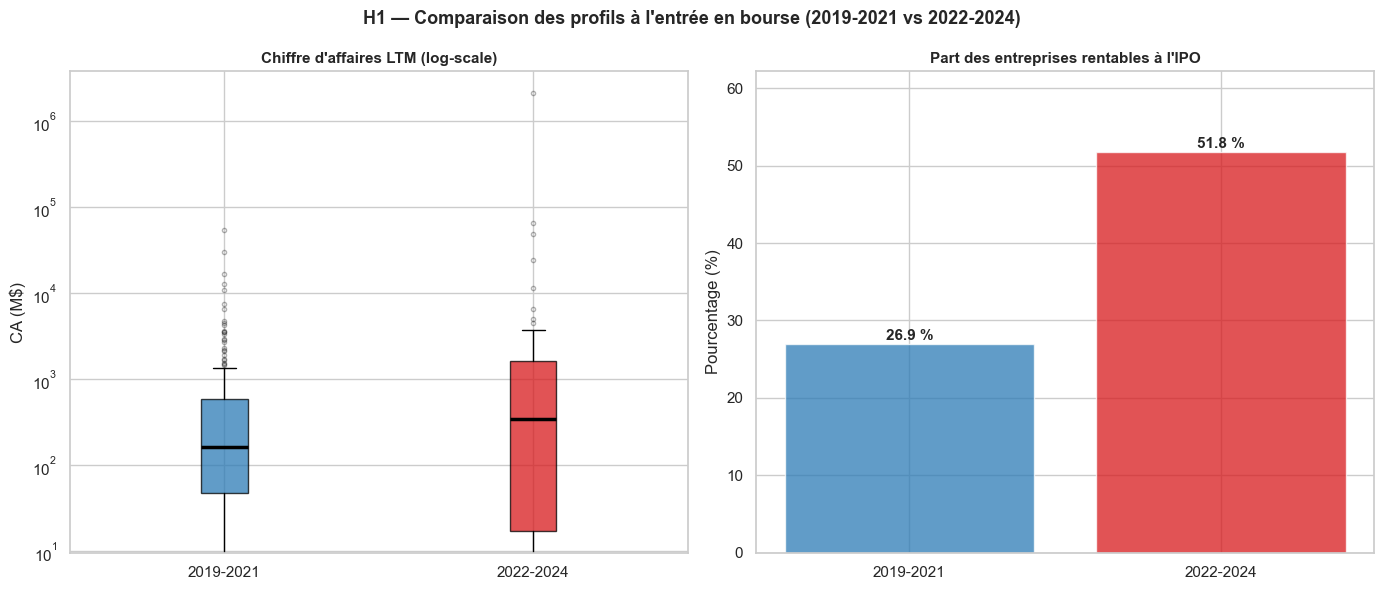

In [6]:
# ── Figure 1 : Boxplot des revenus LTM ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("H1 — Comparaison des profils à l'entrée en bourse (2019-2021 vs 2022-2024)",
             fontsize=13, fontweight="bold")

# 1a. Boxplot CA (log-scale)
bp = axes[0].boxplot(
    [c1["revenue_ltm"].dropna(), c2["revenue_ltm"].dropna()],
    labels=["2019-2021", "2022-2024"],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2.5),
    flierprops=dict(marker="o", markersize=3, alpha=0.3),
)
bp["boxes"][0].set_facecolor(COLORS["c1"]); bp["boxes"][0].set_alpha(0.75)
bp["boxes"][1].set_facecolor(COLORS["c2"]); bp["boxes"][1].set_alpha(0.75)
axes[0].set_yscale("log")
axes[0].set_title("Chiffre d'affaires LTM (log-scale)", fontsize=11, fontweight="bold")
axes[0].set_ylabel("CA (M$)")

# 1b. Barplot % rentables
pcts = [c1["profitable"].mean()*100, c2["profitable"].mean()*100]
bars = axes[1].bar(["2019-2021", "2022-2024"], pcts,
                   color=[COLORS["c1"], COLORS["c2"]], alpha=0.75)
for bar, pct in zip(bars, pcts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{pct:.1f} %", ha="center", fontweight="bold", fontsize=11)
axes[1].set_title("Part des entreprises rentables à l'IPO", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Pourcentage (%)")
axes[1].set_ylim(0, max(pcts) * 1.2)

plt.tight_layout()
plt.show()


## 3. Intervalles de confiance à 95 %

In [7]:
# ── 3a. IC pour la médiane du CA (Bootstrap) ─────────────────────────────────
def median_ci_bootstrap(data, n_boot=5000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    data = np.asarray(data)
    boots = [np.median(rng.choice(data, len(data), replace=True)) for _ in range(n_boot)]
    lo = np.percentile(boots, 100 * alpha / 2)
    hi = np.percentile(boots, 100 * (1 - alpha / 2))
    return lo, hi

rev_c1 = c1["revenue_ltm"].dropna().values
rev_c2 = c2["revenue_ltm"].dropna().values

ci_rev_c1 = median_ci_bootstrap(rev_c1)
ci_rev_c2 = median_ci_bootstrap(rev_c2)

print("=== CA LTM — Médiane & IC 95 % (Bootstrap) ===")
print(f"  2019-2021 : médiane = {np.median(rev_c1):.1f} M$  |  IC 95 % = [{ci_rev_c1[0]:.1f} ; {ci_rev_c1[1]:.1f}]")
print(f"  2022-2024 : médiane = {np.median(rev_c2):.1f} M$  |  IC 95 % = [{ci_rev_c2[0]:.1f} ; {ci_rev_c2[1]:.1f}]")


=== CA LTM — Médiane & IC 95 % (Bootstrap) ===
  2019-2021 : médiane = 163.2 M$  |  IC 95 % = [140.5 ; 225.4]
  2022-2024 : médiane = 348.2 M$  |  IC 95 % = [171.2 ; 722.4]


In [8]:
# ── 3b. IC pour la proportion d'entreprises rentables (Wilson) ────────────────
from statsmodels.stats.proportion import proportion_confint

n1, k1 = len(c1["profitable"].dropna()), int(c1["profitable"].sum())
n2, k2 = len(c2["profitable"].dropna()), int(c2["profitable"].sum())

ci_prof_c1 = proportion_confint(k1, n1, alpha=0.05, method="wilson")
ci_prof_c2 = proportion_confint(k2, n2, alpha=0.05, method="wilson")

print("=== Part rentable — IC 95 % (Wilson) ===")
print(f"  2019-2021 : proportion = {k1/n1:.2%}  |  IC 95 % = [{ci_prof_c1[0]:.2%} ; {ci_prof_c1[1]:.2%}]")
print(f"  2022-2024 : proportion = {k2/n2:.2%}  |  IC 95 % = [{ci_prof_c2[0]:.2%} ; {ci_prof_c2[1]:.2%}]")


=== Part rentable — IC 95 % (Wilson) ===
  2019-2021 : proportion = 26.92%  |  IC 95 % = [21.35% ; 33.33%]
  2022-2024 : proportion = 51.81%  |  IC 95 % = [41.22% ; 62.24%]


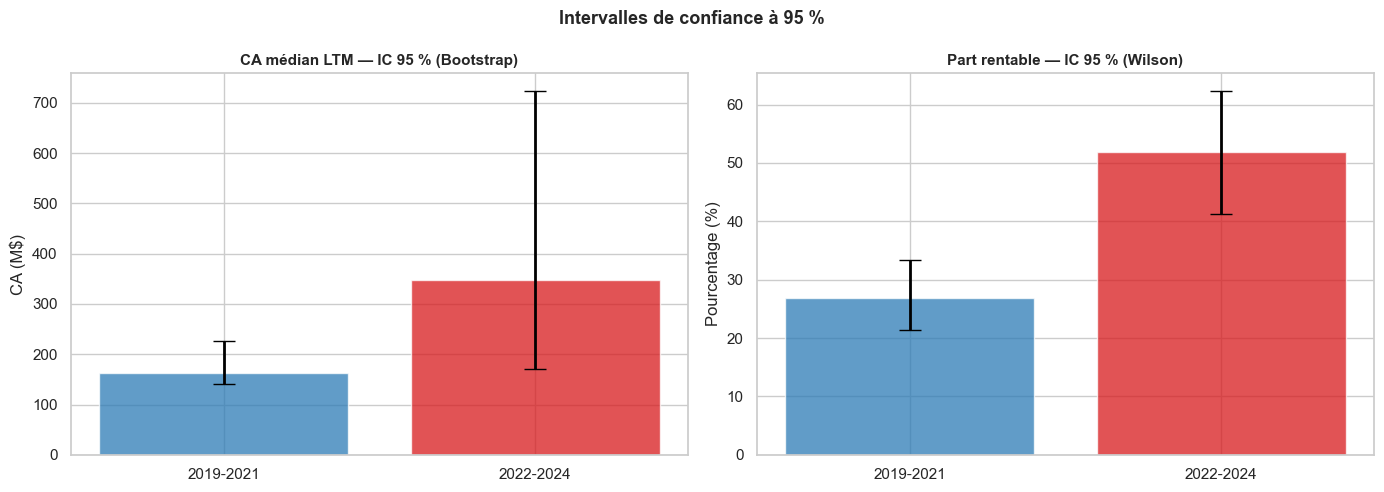

In [9]:
# ── Figure 2 : Visualisation des IC ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Intervalles de confiance à 95 %", fontsize=13, fontweight="bold")

cohorts = ["2019-2021", "2022-2024"]
colors  = [COLORS["c1"], COLORS["c2"]]

# CA médiane
medians_rev = [np.median(rev_c1), np.median(rev_c2)]
errs_rev    = [
    [medians_rev[0] - ci_rev_c1[0], medians_rev[1] - ci_rev_c2[0]],
    [ci_rev_c1[1]  - medians_rev[0], ci_rev_c2[1]  - medians_rev[1]],
]
axes[0].bar(cohorts, medians_rev, color=colors, alpha=0.75,
            yerr=errs_rev, capsize=8, error_kw=dict(elinewidth=2, ecolor="black"))
axes[0].set_title("CA médian LTM — IC 95 % (Bootstrap)", fontsize=11, fontweight="bold")
axes[0].set_ylabel("CA (M$)")

# % rentable
props     = [k1/n1*100, k2/n2*100]
errs_prof = [
    [props[0] - ci_prof_c1[0]*100, props[1] - ci_prof_c2[0]*100],
    [ci_prof_c1[1]*100 - props[0], ci_prof_c2[1]*100 - props[1]],
]
axes[1].bar(cohorts, props, color=colors, alpha=0.75,
            yerr=errs_prof, capsize=8, error_kw=dict(elinewidth=2, ecolor="black"))
axes[1].set_title("Part rentable — IC 95 % (Wilson)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Pourcentage (%)")

plt.tight_layout()
plt.show()


## 4. Tests statistiques

In [10]:
# ── 4a. Test de Mann-Whitney U — CA LTM ─────────────────────────────────────
#
# H0 : la distribution du CA LTM est identique dans les deux cohortes
# H1 : le CA de la cohorte 2022-2024 est significativement supérieur (alternative='greater')
#      (ici les valeurs de c2 sont plus grandes que celles de c1)

stat_mw, p_mw = stats.mannwhitneyu(rev_c2, rev_c1, alternative="greater")

print("=" * 55)
print("  Test de Mann-Whitney U — Chiffre d'affaires LTM")
print("=" * 55)
print(f"  U = {stat_mw:.0f}  |  p-value = {p_mw:.4f}")
if p_mw < 0.05:
    print("  ✓ Significatif (α=5 %) : la cohorte 2022-2024 présente")
    print("    un CA LTM significativement plus élevé.")
else:
    print("  ✗ Non significatif (α=5 %) : pas de différence prouvée")
    print("    sur le CA LTM entre les deux cohortes.")


  Test de Mann-Whitney U — Chiffre d'affaires LTM
  U = 9699  |  p-value = 0.0499
  ✓ Significatif (α=5 %) : la cohorte 2022-2024 présente
    un CA LTM significativement plus élevé.


In [11]:
# ── 4b. Test Z — Proportions d'entreprises rentables ────────────────────────
#
# H0 : les proportions rentables sont égales dans les deux cohortes
# H1 : la proportion de 2022-2024 est supérieure à celle de 2019-2021

count = np.array([k2, k1])
nobs  = np.array([n2, n1])
stat_z, p_z = proportions_ztest(count, nobs, alternative="larger")

print("=" * 55)
print("  Test Z — Part d'entreprises rentables")
print("=" * 55)
print(f"  Z = {stat_z:.4f}  |  p-value = {p_z:.4f}")
if p_z < 0.05:
    print("  ✓ Significatif (α=5 %) : la cohorte 2022-2024 présente")
    print("    une part de rentables significativement plus élevée.")
else:
    print("  ✗ Non significatif (α=5 %) : pas de différence prouvée")
    print("    sur la part rentable entre les deux cohortes.")


  Test Z — Part d'entreprises rentables
  Z = 4.0455  |  p-value = 0.0000
  ✓ Significatif (α=5 %) : la cohorte 2022-2024 présente
    une part de rentables significativement plus élevée.


## 5. Analyse des biais possibles

> Un changement de composition sectorielle entre les deux cohortes pourrait
> expliquer (ou masquer) les différences observées.  Par exemple, la
> surreprésentation de la Biotech (typiquement pré-rentable) dans la cohorte
> 2019-2021 peut artificiellement abaisser la médiane de rentabilité.

sector,Consumer,Finance,Healthcare,Industrials,Other,Tech
cohort_period,,,,,,
2019-2021,17.3,10.6,2.4,35.1,3.8,30.8
2022-2024,14.5,18.1,6.0,43.4,6.0,12.0


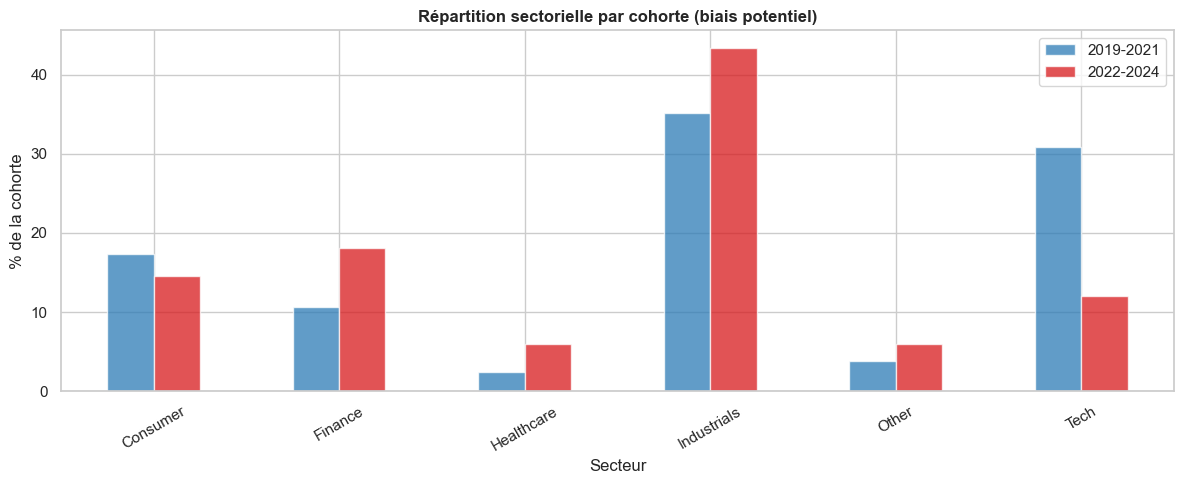

In [12]:
# ── 5a. Répartition sectorielle ─────────────────────────────────────────────
sector_pct = pd.crosstab(df["cohort_period"], df["sector"],
                         normalize="index").mul(100).round(1)
display(sector_pct)

fig, ax = plt.subplots(figsize=(12, 5))
sector_pct.T.plot(kind="bar", ax=ax, color=[COLORS["c1"], COLORS["c2"]], alpha=0.75)
ax.set_title("Répartition sectorielle par cohorte (biais potentiel)", fontsize=12,
             fontweight="bold")
ax.set_ylabel("% de la cohorte")
ax.set_xlabel("Secteur")
ax.tick_params(axis="x", rotation=30)
ax.legend(["2019-2021", "2022-2024"])
plt.tight_layout()
plt.show()


In [13]:
# ── 5b. Test de Mann-Whitney intra-secteur (Tech) ────────────────────────────
#
# On vérifie si la différence de CA persiste même au sein d'un seul secteur.
# Ici : secteur "Tech" (à adapter si votre colonne sector diffère).

for sec in df["sector"].dropna().unique():
    g1 = c1.loc[c1["sector"] == sec, "revenue_ltm"].dropna()
    g2 = c2.loc[c2["sector"] == sec, "revenue_ltm"].dropna()
    if len(g1) >= 5 and len(g2) >= 5:
        stat_s, p_s = stats.mannwhitneyu(g2, g1, alternative="greater")
        sig = "✓" if p_s < 0.05 else "✗"
        print(f"  {sig} Secteur {sec:<15} | n(c1)={len(g1):3d}  n(c2)={len(g2):3d}"
              f"  | méd_c1={g1.median():.0f} M$  méd_c2={g2.median():.0f} M$"
              f"  | p={p_s:.4f}")


  ✗ Secteur Tech            | n(c1)= 64  n(c2)= 10  | méd_c1=154 M$  méd_c2=217 M$  | p=0.3376
  ✗ Secteur Consumer        | n(c1)= 36  n(c2)= 12  | méd_c1=403 M$  méd_c2=592 M$  | p=0.5427
  ✓ Secteur Healthcare      | n(c1)=  5  n(c2)=  5  | méd_c1=65 M$  méd_c2=3741 M$  | p=0.0040
  ✗ Secteur Finance         | n(c1)= 22  n(c2)= 15  | méd_c1=148 M$  méd_c2=1148 M$  | p=0.2941
  ✗ Secteur Other           | n(c1)=  8  n(c2)=  5  | méd_c1=195 M$  méd_c2=189 M$  | p=0.5284
  ✗ Secteur Industrials     | n(c1)= 73  n(c2)= 36  | méd_c1=63 M$  méd_c2=193 M$  | p=0.2046


## 6. Régression OLS multivariée (variables de contrôle)

La régression permet de vérifier si l'appartenance à la cohorte 2022-2024
(variable `is_post_2021`) prédit l'underpricing, tout en contrôlant
pour la **taille** (`log_size`), la **rentabilité** (`profitable`) et le
**chiffre d'affaires** (`log_rev`).


In [14]:
# ── 6. OLS : underpricing ~ cohorte + taille + rentabilité + log_rev ─────────
df_ols = df.copy()
df_ols["is_post_2021"] = (df_ols["cohort_period"] == "2022-2024").astype(int)
df_ols["log_size"] = np.log1p(df_ols["ipo_size_m"].clip(lower=0.01))
df_ols["log_rev"]  = np.log1p(df_ols["revenue_ltm"].clip(lower=0.01))

x_cols = ["is_post_2021", "log_size", "profitable", "log_rev"]
y_col  = "underpricing"

df_ols_clean = df_ols[[y_col] + x_cols].replace([np.inf, -np.inf], np.nan).dropna()
X = sm.add_constant(df_ols_clean[x_cols])
y = df_ols_clean[y_col]

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           underpricing   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.7890
Date:              mar., 28 avr. 2026   Prob (F-statistic):              0.533
Time:                        13:26:42   Log-Likelihood:                 46.615
No. Observations:                 291   AIC:                            -83.23
Df Residuals:                     286   BIC:                            -64.86
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0867      0.065      1.341   

## 7. Synthèse et conclusion

| Critère | 2019-2021 | 2022-2024 | Test | Résultat |
|---|---|---|---|---|
| CA médian LTM (M$) | *(voir ci-dessus)* | *(voir ci-dessus)* | Mann-Whitney U | *voir p-value* |
| Part rentable (%) | *(voir ci-dessus)* | *(voir ci-dessus)* | Test Z | *voir p-value* |

**Lecture** :
- Si les deux p-values sont < 0,05 → **H1 confirmée** : la cohorte 2022-2024 est plus sélective.
- Si une seule est significative → **H1 partiellement confirmée**.
- Si aucune n'est significative → **H1 non confirmée** sur ces données.

**Biais potentiels identifiés** :
- Changement de composition sectorielle entre les deux périodes.
- Données `revenue_ltm` / `profitable` potentiellement manquantes ou simulées
  (voir cellule 1f) — à remplacer par les données réelles du fichier SCOOP.
